# Introduction

Brick kilns are a significant source of air pollution in India, and monitoring their temporal patterns is crucial for environmental management. Traditional approaches require manual inspection of satellite imagery across multiple years, which is time-consuming and prone to inconsistency.

In this notebook, we demonstrate how **Gemini 3 Pro's multi-image context capability** can analyze temporal changes in a single API call. We have satellite images of the same location (28.212481°N, 77.401398°E) captured across multiple years (2014-2022), and we ask Gemini to:

1. Identify when brick kilns first appear
2. Determine the type of kilns (e.g., Bull's Trench Kiln, Fixed Chimney Kiln, Zig-zag kiln)
3. Track changes in kiln count and configuration over time
4. Detect patterns in kiln operations (active vs. inactive periods)

This approach leverages Gemini's ability to process multiple images in a single context, eliminating the need for sequential processing and maintaining temporal coherence across the analysis.

# Setup

In [1]:
import os
import glob
import re
from google import genai
from PIL import Image
import matplotlib.pyplot as plt
import json

# Initialize Gemini client
if 'GEMINI_API_KEY' not in os.environ:
    raise ValueError(
        "GEMINI_API_KEY not found in environment.\n"
        "Set it with: export GEMINI_API_KEY='your-key'\n"
        "Get your key at: https://aistudio.google.com/apikey"
    )

client = genai.Client(api_key=os.environ['GEMINI_API_KEY'])
MODEL = "models/gemini-3-pro-preview"

print(f"Gemini client initialized")
print(f"Using model: {MODEL}")

%config InlineBackend.figure_format = 'retina'

/Users/nipun/base/lib/python3.12/site-packages/pydantic/_internal/_fields.py:186: UserWarning: Field name "name" shadows an attribute in parent "Operation"; 
  warnings.warn(
/Users/nipun/base/lib/python3.12/site-packages/pydantic/_internal/_fields.py:186: UserWarning: Field name "metadata" shadows an attribute in parent "Operation"; 
  warnings.warn(
/Users/nipun/base/lib/python3.12/site-packages/pydantic/_internal/_fields.py:186: UserWarning: Field name "done" shadows an attribute in parent "Operation"; 
  warnings.warn(
/Users/nipun/base/lib/python3.12/site-packages/pydantic/_internal/_fields.py:186: UserWarning: Field name "error" shadows an attribute in parent "Operation"; 
  warnings.warn(


Gemini client initialized
Using model: models/gemini-3-pro-preview


# Load and Visualize Temporal Image Series

In [2]:
# Get all brick kiln images and sort by year
image_folder = "brick-kilns"
image_files = sorted(glob.glob(f"{image_folder}/*.png"))

print(f"Found {len(image_files)} images:")
for f in image_files:
    print(f"  {os.path.basename(f)}")

Found 5 images:
  28.212481_77.401398_2014.png
  28.212481_77.401398_2016.png
  28.212481_77.401398_2018.png
  28.212481_77.401398_2020.png
  28.212481_77.401398_2022.png


In [4]:
# Extract coordinates and years from filenames
def parse_filename(filename):
    """Extract lat, lon, year from filename like 28.212481_77.401398_2014.png"""
    basename = os.path.basename(filename)
    parts = basename.replace('.png', '').split('_')
    return {
        'lat': float(parts[0]),
        'lon': float(parts[1]),
        'year': int(parts[2]),
        'path': filename
    }

# Parse all images
image_data = [parse_filename(f) for f in image_files]
image_data = sorted(image_data, key=lambda x: x['year'])

# Load images
images = [Image.open(item['path']) for item in image_data]
years = [item['year'] for item in image_data]
location = f"{image_data[0]['lat']}°N, {image_data[0]['lon']}°E"

print(f"\nLocation: {location}")
print(f"Years: {years}")
print(f"Time span: {years[-1] - years[0]} years ({years[0]}-{years[-1]})")


Location: 28.212481°N, 77.401398°E
Years: [2014, 2016, 2018, 2020, 2022]
Time span: 8 years (2014-2022)


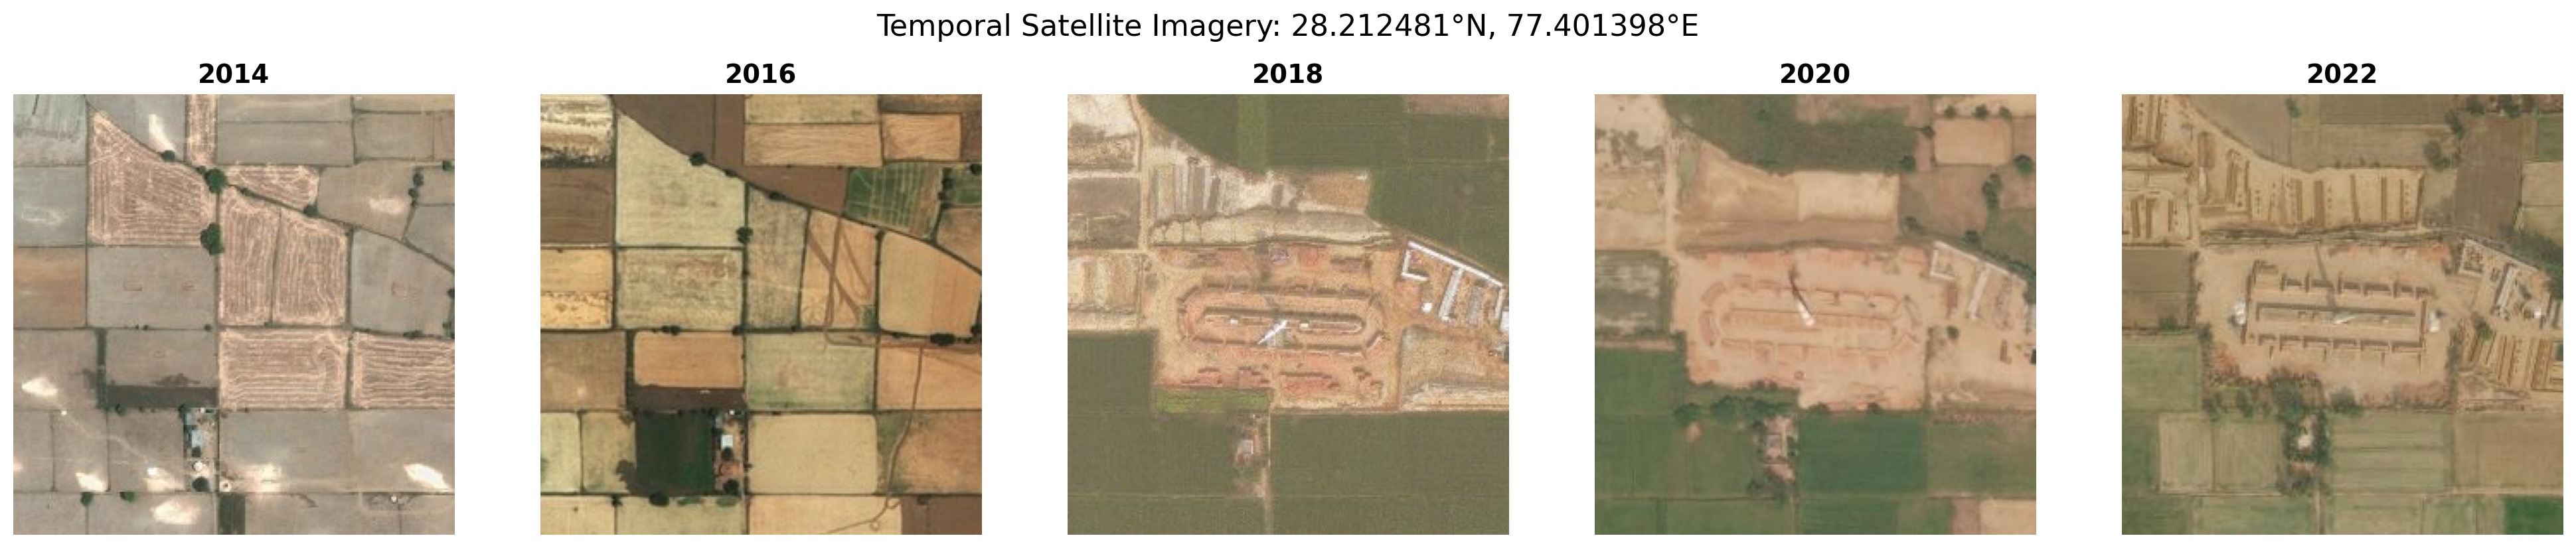

In [5]:
# Visualize the temporal sequence
n_images = len(images)
fig, axes = plt.subplots(1, n_images, figsize=(4*n_images, 4))

if n_images == 1:
    axes = [axes]

for ax, img, year in zip(axes, images, years):
    ax.imshow(img)
    ax.set_title(f"{year}", fontsize=14, fontweight='bold')
    ax.axis('off')

plt.suptitle(f"Temporal Satellite Imagery: {location}", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Multi-Image Temporal Analysis with Gemini 3 Pro

We now send all images in a **single API call** with a comprehensive prompt asking Gemini to analyze temporal patterns across the entire sequence.

In [ ]:
# Construct multi-image prompt with temporal context
contents = []

# Add each image with its year label
for year, img in zip(years, images):
    contents.append(f"**Year {year}:**")
    contents.append(img)

# Improved prompt with better kiln type identification guidance
prompt = f"""I have provided {len(images)} satellite images of the same location ({location}) taken across different years: {', '.join(map(str, years))}.

These images show brick kilns in this region. Analyze chronologically and identify changes.

**CRITICAL: Kiln Type Visual Identification Guide:**

1. **Fixed Chimney Bull's Trench Kiln (FCBTK)**: 
   - Shape: **OVAL or CIRCULAR** with smooth curved edges
   - Center: Single tall chimney casting a shadow
   - Pattern: Curved/circular brick stacking pattern
   
2. **Zig-zag Kiln (Modern, Efficient)**:
   - Shape: **RECTANGULAR** with sharp 90-degree corners
   - Edges: Straight lines, NOT curved
   - Pattern: Rectangular grid-like arrangement
   - Often has multiple chambers in a line
   
3. **Clamp Kiln**: Temporary mounds, no permanent structure

**Look carefully at the SHAPE:**
- If you see **OVAL/ROUND** = FCBTK
- If you see **RECTANGULAR with sharp corners** = Zig-zag Kiln
- If the shape CHANGES from oval to rectangular across years = Type evolution!

For each year, provide:
- Year
- Kilns present? (true/false)
- Kiln type (look at SHAPE carefully!)
- Kiln count (number)
- Notes about what you observe

Return ONLY valid JSON (no markdown, no explanation before/after):

{{
  "first_year": <year when kilns first appear>,
  "years": [
    {{
      "year": <year>,
      "has_kilns": <true|false>,
      "type": "<FCBTK|Zigzag|None>",
      "count": <number>,
      "notes": "<brief observation>"
    }}
  ],
  "evolution": "<describe type changes if any>"
}}

IMPORTANT: 
- Return ONLY the JSON object, nothing else
- Check if shape is oval (FCBTK) or rectangular (Zigzag)
- Mention if type changes across years!
"""

contents.append(prompt)

print(f"Sending {len(images)} images to Gemini 3 Pro for temporal analysis...")
print(f"Years: {years}")
print("\nThis may take 30-60 seconds...\n")

In [7]:
# Send request to Gemini
import time

start_time = time.time()

response = client.models.generate_content(
    model=MODEL,
    contents=contents
)

elapsed_time = time.time() - start_time

print(f"Analysis complete in {elapsed_time:.2f} seconds")
print(f"\nProcessing rate: {len(images)/elapsed_time:.2f} images/second")

Analysis complete in 43.28 seconds

Processing rate: 0.12 images/second


# Analysis Results

In [8]:
# Display raw response
print("="*80)
print("RAW RESPONSE FROM GEMINI 3 PRO")
print("="*80)
print(response.text)
print("="*80)

RAW RESPONSE FROM GEMINI 3 PRO
Based on the analysis of the provided satellite imagery for the coordinates 28.212481°N, 77.401398°E, here is the detailed assessment in the requested JSON format.

```json
{
  "first_appearance_year": 2018,
  "yearly_analysis": [
    {
      "year": 2014,
      "kilns_present": false,
      "kiln_types": [],
      "kiln_count": 0,
      "operational_status": "inactive",
      "spatial_arrangement": "N/A",
      "observations": "The area is purely agricultural. The land consists of subdivided rectangular fields with varying stages of cultivation (some fallow/brown, some with light vegetation). A small farm structure/house is visible at the bottom center."
    },
    {
      "year": 2016,
      "kilns_present": false,
      "kiln_types": [],
      "kiln_count": 0,
      "operational_status": "inactive",
      "spatial_arrangement": "N/A",
      "observations": "The site remains agricultural. The field patterns are consistent with 2014, showing crop rotatio

In [ ]:
# Improved JSON parser
def parse_response(response_text):
    """Extract JSON from response, handling various formats."""
    import re
    
    text = response_text.strip()
    
    # Method 1: Try to find JSON in markdown code blocks
    json_match = re.search(r'```(?:json)?\s*(\{.*?\})\s*```', text, re.DOTALL)
    if json_match:
        try:
            return json.loads(json_match.group(1))
        except json.JSONDecodeError:
            pass
    
    # Method 2: Try to find any JSON object (between { and })
    json_match = re.search(r'(\{[^{]*?"first_year".*?\})\s*$', text, re.DOTALL)
    if json_match:
        try:
            return json.loads(json_match.group(1))
        except json.JSONDecodeError:
            pass
    
    # Method 3: Find largest {...} block
    brace_starts = [i for i, c in enumerate(text) if c == '{']
    for start in brace_starts:
        # Find matching closing brace
        count = 0
        for end in range(start, len(text)):
            if text[end] == '{':
                count += 1
            elif text[end] == '}':
                count -= 1
                if count == 0:
                    try:
                        return json.loads(text[start:end+1])
                    except json.JSONDecodeError:
                        continue
    
    print("❌ Could not extract valid JSON from response")
    print(f"\nFirst 500 chars of response:\n{text[:500]}")
    return None

analysis_data = parse_response(response.text)

if analysis_data:
    print("✓ Successfully parsed structured analysis")
    print(f"\nExtracted data:")
    print(f"  - First appearance: {analysis_data.get('first_year', 'N/A')}")
    print(f"  - Years analyzed: {len(analysis_data.get('years', []))}")
    print(f"  - Evolution notes: {analysis_data.get('evolution', 'N/A')[:80]}...")
else:
    print("⚠ Using raw text response (JSON parsing failed)")

## Key Findings

In [ ]:
if analysis_data:
    print("\n" + "="*80)
    print("KEY FINDINGS")
    print("="*80)
    
    print(f"\n📍 Location: {location}")
    print(f"📅 Time Period: {years[0]}-{years[-1]} ({years[-1]-years[0]} years)")
    
    if 'first_year' in analysis_data:
        print(f"\n🏭 First Appearance: {analysis_data['first_year']}")
    
    if 'evolution' in analysis_data:
        print(f"\n📈 Evolution: {analysis_data['evolution']}")
    
    # Show year-by-year summary
    if 'years' in analysis_data:
        print(f"\n📊 Year-by-Year Summary:")
        for year_data in analysis_data['years']:
            year = year_data.get('year')
            has_kilns = year_data.get('has_kilns', False)
            kiln_type = year_data.get('type', 'None')
            count = year_data.get('count', 0)
            
            status = "✓" if has_kilns else "✗"
            print(f"  {year}: {status} Type={kiln_type}, Count={count}")
    
    print("\n" + "="*80)

## Year-by-Year Analysis

In [ ]:
if analysis_data and 'years' in analysis_data:
    print("\n" + "="*80)
    print("DETAILED YEAR-BY-YEAR ANALYSIS")
    print("="*80)
    
    for year_data in analysis_data['years']:
        year = year_data.get('year', 'Unknown')
        has_kilns = year_data.get('has_kilns', False)
        kiln_type = year_data.get('type', 'None')
        count = year_data.get('count', 0)
        notes = year_data.get('notes', '')
        
        print(f"\n📅 **Year {year}**")
        print("-" * 50)
        print(f"  Kilns Present: {'✓ Yes' if has_kilns else '✗ No'}")
        
        if has_kilns:
            print(f"  Type: {kiln_type}")
            print(f"  Count: {count}")
        
        if notes:
            print(f"  Notes: {notes}")
    
    print("\n" + "="*80)
else:
    print("⚠ No structured yearly data available")

## Visualization: Temporal Timeline

In [ ]:
if analysis_data and 'years' in analysis_data:
    # Extract data for visualization
    vis_years = []
    kiln_counts = []
    kiln_present = []
    kiln_types = []
    
    for year_data in analysis_data['years']:
        vis_years.append(year_data.get('year'))
        has_kilns = year_data.get('has_kilns', False)
        kiln_present.append(1 if has_kilns else 0)
        kiln_counts.append(year_data.get('count', 0))
        kiln_types.append(year_data.get('type', 'None'))
    
    # Create visualization
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    
    # Plot 1: Kiln presence over time
    ax1 = axes[0]
    ax1.fill_between(vis_years, kiln_present, alpha=0.3, color='orange', label='Kilns Present')
    ax1.plot(vis_years, kiln_present, marker='o', markersize=10, color='darkorange', linewidth=2)
    ax1.set_ylabel('Kiln Presence', fontsize=12, fontweight='bold')
    ax1.set_ylim(-0.1, 1.1)
    ax1.set_yticks([0, 1])
    ax1.set_yticklabels(['No', 'Yes'])
    ax1.grid(True, alpha=0.3)
    ax1.set_title('Brick Kiln Presence Over Time', fontsize=14, fontweight='bold')
    ax1.legend()
    
    # Plot 2: Kiln count over time
    ax2 = axes[1]
    bars = ax2.bar(vis_years, kiln_counts, color='steelblue', alpha=0.7, edgecolor='darkblue', linewidth=1.5)
    ax2.set_ylabel('Number of Kilns', fontsize=12, fontweight='bold')
    ax2.set_title('Brick Kiln Count Over Time', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for year, count, bar in zip(vis_years, kiln_counts, bars):
        if count > 0:
            ax2.text(year, count + 0.05, str(int(count)), ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    # Plot 3: Kiln type evolution
    ax3 = axes[2]
    type_colors = {'FCBTK': 'coral', 'Zigzag': 'limegreen', 'None': 'lightgray'}
    type_numeric = [1 if t == 'FCBTK' else 2 if t == 'Zigzag' else 0 for t in kiln_types]
    
    for i, (year, type_val, type_name) in enumerate(zip(vis_years, type_numeric, kiln_types)):
        color = type_colors.get(type_name, 'gray')
        ax3.bar(year, 1, color=color, alpha=0.8, edgecolor='black', linewidth=1.5, label=type_name if type_name not in [k.split()[0] for k in ax3.get_legend_handles_labels()[1]] else "")
        ax3.text(year, 0.5, type_name, ha='center', va='center', fontsize=10, fontweight='bold')
    
    ax3.set_xlabel('Year', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Kiln Type', fontsize=12, fontweight='bold')
    ax3.set_ylim(0, 1.2)
    ax3.set_yticks([])
    ax3.set_title('Kiln Type Evolution', fontsize=14, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='x')
    
    # Create custom legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='coral', edgecolor='black', label='FCBTK (Oval)'),
                      Patch(facecolor='limegreen', edgecolor='black', label='Zigzag (Rectangular)'),
                      Patch(facecolor='lightgray', edgecolor='black', label='None')]
    ax3.legend(handles=legend_elements, loc='upper right')
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠ Visualization skipped: Structured data not available")

# Conclusions

## Key Insights

This analysis demonstrates several important capabilities:

1. **Multi-Image Temporal Context**: Gemini 3 Pro can effectively process multiple satellite images in a single API call, maintaining temporal coherence across years.

2. **Detailed Visual Analysis**: The model can identify specific infrastructure types (kiln types), operational status, and spatial patterns from satellite imagery.

3. **Structured Output**: By requesting JSON format, we can programmatically extract and visualize temporal trends.

4. **Efficiency**: Processing multiple years in a single context is more efficient than sequential analysis and ensures consistent interpretation across the time series.

## Environmental Monitoring Applications

This approach can be applied to:
- **Air Quality Management**: Track pollution sources over time
- **Regulatory Compliance**: Monitor unauthorized constructions
- **Urban Planning**: Assess industrial expansion patterns
- **Climate Studies**: Correlate infrastructure changes with environmental indicators

## Limitations

- Satellite resolution affects detection accuracy
- Seasonal variations (e.g., crop burning, monsoon) can affect visibility
- Ground truth validation recommended for policy decisions
- Model may have uncertainty in distinguishing similar structures

## Future Work

- Test on larger temporal datasets (more locations, longer time spans)
- Compare with traditional computer vision approaches
- Validate findings with ground truth data
- Automate large-scale monitoring across regions

# References

- [Gemini API Documentation](https://ai.google.dev/gemini-api/docs)
- [Previous Post: Batch vs Sequential Processing](https://nipunbatra.github.io/blog/posts/2025-12-12-gemini-batch-vs-sequential.html)
- [Brick Kiln Environmental Impact Studies](https://www.cseindia.org/)
- Location: 28.212481°N, 77.401398°E (Delhi NCR region)